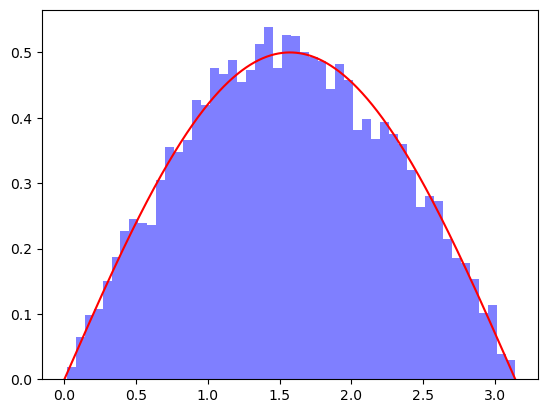

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def sample_from_distribution(model, n_samples=1000, device=device, box = [0,torch.pi]):
    
    x = torch.rand(n_samples, 1, device=device) * (box[1] - box[0]) + box[0]
    model_old = model(x)
    with torch.no_grad():
        for _ in range(n_samples):
            x_new = x + torch.randn_like(x) * 0.1  # Small perturbation
            model_new = model(x_new)
            acceptance_ratio = ((model_new) / (model_old)).clamp(max=1.0)
            accept = torch.rand_like(acceptance_ratio) < acceptance_ratio
            x = torch.where(accept, x_new, x)
            model_old = model(x)
    return x

class sin(nn.Module):
    def __init__(self):
        super(sin, self).__init__()

    def forward(self, x):
        return torch.sin(x)

model = sin().to(device)

x = sample_from_distribution(model, n_samples=10_000, device=device)

plt.hist(x.cpu().numpy(), bins=50, density=True, alpha=0.5, color='blue')

analytic_model = model(torch.linspace(0, torch.pi, 1000).to(device))
norm = (torch.trapz(analytic_model, torch.linspace(0, torch.pi, 1000).to(device)))
analytic_model = analytic_model / norm

plt.plot(torch.linspace(0, torch.pi, 1000).cpu().numpy(), analytic_model.cpu().numpy(), color='red')

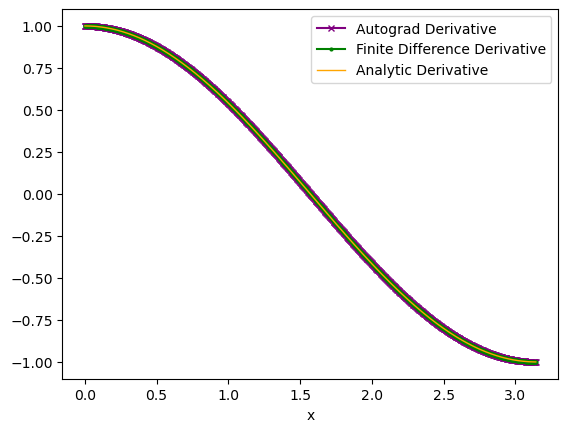

In [12]:
def finite_difference_derivative(model, x):
    # if isinstance(model,(nn.Module, callable)):
    #     y = model(x)
    # else:
    #     y = model
    y = model(x)
    dy_dx = torch.zeros_like(y)
    h = x[2] - x[1]  # Use the spacing between points as step size
    dy_dx[1:-1] = (y[2:]-y[0:-2]) / (2 * h)  # Central difference for interior points
    dy_dx[0] = (y[1] - y[0]) / h  # Forward difference for the first point
    dy_dx[-1] = (y[-1] - y[-2]) / h

    return dy_dx

def compute_autograd_derivative(model, x):
    x.requires_grad = True
    # if isinstance(model,nn.Module):
    #     y = model(x)
    # else:
    #     y = model
    y = model(x)
    dy_dx = torch.autograd.grad(y, x, create_graph=True, grad_outputs=torch.ones_like(y))[0]
    return dy_dx

autograd_dsin = compute_autograd_derivative(model, torch.linspace(0, torch.pi, 1000).to(device))
plt.plot(torch.linspace(0, torch.pi, 1000).cpu().numpy(), autograd_dsin.cpu().detach().numpy(), color='purple', label='Autograd Derivative', marker='x', markersize=4)

dsin = finite_difference_derivative(model, torch.linspace(0, torch.pi, 1000).to(device))
plt.plot(torch.linspace(0,torch.pi,1000), dsin.cpu().numpy(), color='green', label='Finite Difference Derivative', marker='o', markersize=2)
plt.plot(torch.linspace(0, torch.pi, 1000).cpu().numpy(), torch.cos(torch.linspace(0, torch.pi, 1000)).cpu().numpy(), color='orange', label='Analytic Derivative', linewidth=1)
plt.xlabel('x')
plt.legend()

In [13]:
def integral(model, x):
    if isinstance(model, nn.Module):
        y = model(x)
    else:
        y = model
    integral_value = torch.trapz(y, x)
    return integral_value

def mc_integral(model, n_samples=1000, device=device):
    x_samples = torch.rand(n_samples, 1, device=device) * (torch.pi - 0) + 0
    y_samples = model(x_samples)
    integral_value = torch.mean(y_samples) * (torch.pi - 0)
    return integral_value

L = 2

x = torch.linspace(0, torch.pi, 1000).to(device)
integral_value = integral(model, x)
mc_integral_value = mc_integral(model, n_samples=5000, device=device)
print(f"Integral value (Trapezoid): {integral_value.item()}")
print(f"Integral value (MC): {mc_integral_value.item()}")

Integral value (Trapezoid): 1.9999984502792358
Integral value (MC): 1.9997758865356445


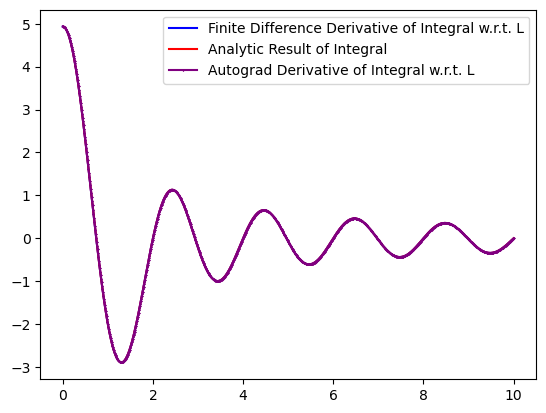

In [18]:
class sin_lx(nn.Module):
    def __init__(self, L=2):
        super(sin_lx, self).__init__()
        self.L = L

    def forward(self, x):
        return torch.sin(self.L * x)
    
def der_integral(L):
    x = torch.linspace(0, torch.pi, 1000).to(device)
    result = torch.zeros_like(x)
    for i in range(len(L)):
        l = L[i]
        # COMPUTED WITH WOLFRAM ALPHA
        # https://www.wolframalpha.com/input?i=derivative+with+respect+to+L+of+integral+of+sin%28x*L%29+from+0+to+pi
        result[i] = (torch.pi*l*torch.sin(torch.pi*l)+torch.cos(torch.pi*l)-1)/(l**2)
    return result

def f(L):
    integral_result = torch.zeros_like(L)
    for i in range(len(L)):
        sin_lx_model = sin_lx(L[i]).to(device)
        x = torch.linspace(0, torch.pi, 1000).to(device)
        integral_value = integral(sin_lx_model, x)
        integral_result[i] = integral_value
    return integral_result

L_values = torch.linspace(0.0, 10, 1000).to(device)
df_dl = finite_difference_derivative(f, L_values)
y = f(L_values)
y.requires_grad = True
autograd_df_dl = compute_autograd_derivative(f, L_values)
plt.plot(L_values.detach().cpu().numpy(), df_dl.detach().cpu().numpy(), label='Finite Difference Derivative of Integral w.r.t. L', color='blue')
plt.plot(L_values.detach().cpu().numpy(), der_integral(L_values).detach().cpu().numpy(), label='Analytic Result of Integral', color='red')
plt.plot(L_values.detach().cpu().numpy(), autograd_df_dl.detach().cpu().numpy(), label='Autograd Derivative of Integral w.r.t. L', color='purple', marker='x', markersize=1)

plt.legend()

$$f(\lambda) = \int_0^\pi \sin(x\lambda)dx$$

In [ ]:
class T_int_sin_lx_dx(nn.Module):
    def __init__(self, L=2):
        super(T_int_sin_lx_dx, self).__init__()

    def forward(self, L):
        x = torch.linspace(0, torch.pi, 1000).to(device)
        result = torch.zeros_like(x)
        for i in range(len(L)):
            L_i = L[i]
            result[i] = torch.trapz(torch.sin(L_i * x), x)
        return result
    
class MC_int_sin_lx_dx(nn.Module):
    def __init__(self, L=2, n_samples=100_000, device=device):
        super(MC_int_sin_lx_dx, self).__init__()
        self.L = L
        self.n_samples = n_samples
        self.device = device

    def forward(self, L):
        
        result = torch.zeros_like(L)
        for i in range(len(L)):
            L_i = L[i]
            x_samples = torch.rand(self.n_samples, 1, device=self.device) * (torch.pi - 0) + 0
            y_samples = torch.sin(L_i * x_samples)
            integral_value = torch.mean(y_samples) * (torch.pi - 0)
            result[i] = integral_value
        return result


def analytic_result(L):
    """
    Computes the analytic result of the integral of sin(L*x) from 0 to pi
    with respect to L.
    """
    result = torch.zeros_like(L)
    for i in range(len(L)):
        # COMPUTED WITH WOLFRAM ALPHA
        L_i = L[i]
        result[i] = (1-torch.cos(torch.pi * L_i) )/L_i
    return result

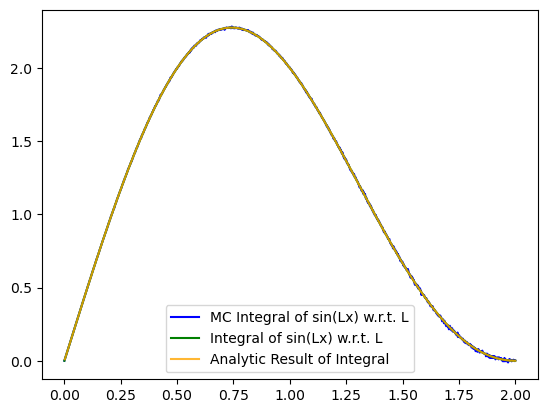

In [43]:
L_vals = torch.linspace(0.0, 2, 1000).to(device)
model = T_int_sin_lx_dx().to(device)
mc_model = MC_int_sin_lx_dx().to(device)
mc_y = mc_model(L_vals)
plt.plot(L_vals.cpu().numpy(), mc_y.cpu().numpy(), label='MC Integral of sin(Lx) w.r.t. L', color='blue', markersize=1)
y = model(L_vals)
plt.plot(L_vals.cpu().numpy(), y.cpu().numpy(), label='Integral of sin(Lx) w.r.t. L', color='green', markersize=1)
plt.plot(L_vals.cpu().numpy(), analytic_result(L_vals).cpu().numpy(), label='Analytic Result of Integral', color='orange', alpha=0.8)

plt.legend()